# From Data to Discovery — Lessons from the Titanic Project

**Main theme:** Python transforms raw historical data into insight, prediction, and learning.

This notebook presents a systematic data science case study using the Titanic passenger dataset. The Titanic is a historical dataset and a strong learning case because it combines human context, incomplete records, social structure, and a clear predictive classification question.

**Core workflow:**
```text
Load Data → Clean Data → Explore → Feature Engineer → Custom Imputation → Split → Preprocessing Pipeline → GridSearchCV Model Search → Evaluation & ROC → Odds Coefficients → Predictions
```


## 1. Environment and Library Setup

The notebook uses the standard Python data science stack: NumPy, Pandas, Matplotlib, Seaborn, and Scikit-Learn.
All package imports (including regular expressions `re` for title parsing and cross-validated searches) are declared in this initial cell to prepare the notebook for running in Google Colab cleanly.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn import set_config

set_config(display="diagram")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120


## 2. Dataset Ingestion

This notebook uses the complete OpenML Titanic dataset with 1,309 rows as the main dataset.


In [2]:
import os

# Look for local data first, then fall back to remote URL
possible_paths = [
    "../data/openml_titanic.csv",
    "./data/openml_titanic.csv",
    "/content/openml_titanic.csv",
    "https://www.openml.org/data/get_csv/16826755/phpMYEkMl"
]

df = None
for path_to_try in possible_paths:
    try:
        if path_to_try.startswith("http"):
            df = pd.read_csv(path_to_try)
            print(f"✓ Loaded Titanic dataset from remote URL: {path_to_try}")
        elif os.path.exists(path_to_try):
            df = pd.read_csv(path_to_try)
            print(f"✓ Loaded Titanic dataset from local path: {path_to_try}")
        if df is not None:
            break
    except Exception as e:
        print(f"Could not load from {path_to_try}: {e}")

if df is None:
    raise FileNotFoundError("Could not load the OpenML Titanic dataset from local paths or remote URL.")

display(df.head())
print("Shape:", df.shape)
df.info()


✓ Loaded Titanic dataset from local path: ../data/openml_titanic.csv


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Shape: (1309, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 143.3 KB


## 3. Column Cleaning and Data Dictionary

Column names are normalized to lowercase and punctuation is simplified. OpenML stores some missing values as `?`, so those placeholders are converted to real missing values before analysis.

**Leakage warning:** Do not use `boat` or `body` as model features. They are post-disaster indicators and would leak the target class, causing overfitting and model failure.


In [3]:
df = df.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df = df.replace("?", np.nan)
for numeric_column in ["age", "fare"]:
    df[numeric_column] = pd.to_numeric(df[numeric_column], errors="coerce")

display(pd.DataFrame({"columns": df.columns}))
display(df.head())


,columns
0,pclass
1,survived
2,name
3,sex
4,age
5,sibsp
6,parch
7,ticket
8,fare
9,cabin


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home_dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 4. Missing Value Analysis

Clean data is the foundation of truth. Missing `age`, `cabin`, `embarked`, and `fare` values must be handled carefully.


In [4]:
missing = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
    })
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing)


,missing_count,missing_percent
body,1188,90.76
cabin,1014,77.46
boat,823,62.87
home_dest,564,43.09
age,263,20.09
embarked,2,0.15
fare,1,0.08


## 5. Exploratory Data Analysis


### Survival Count


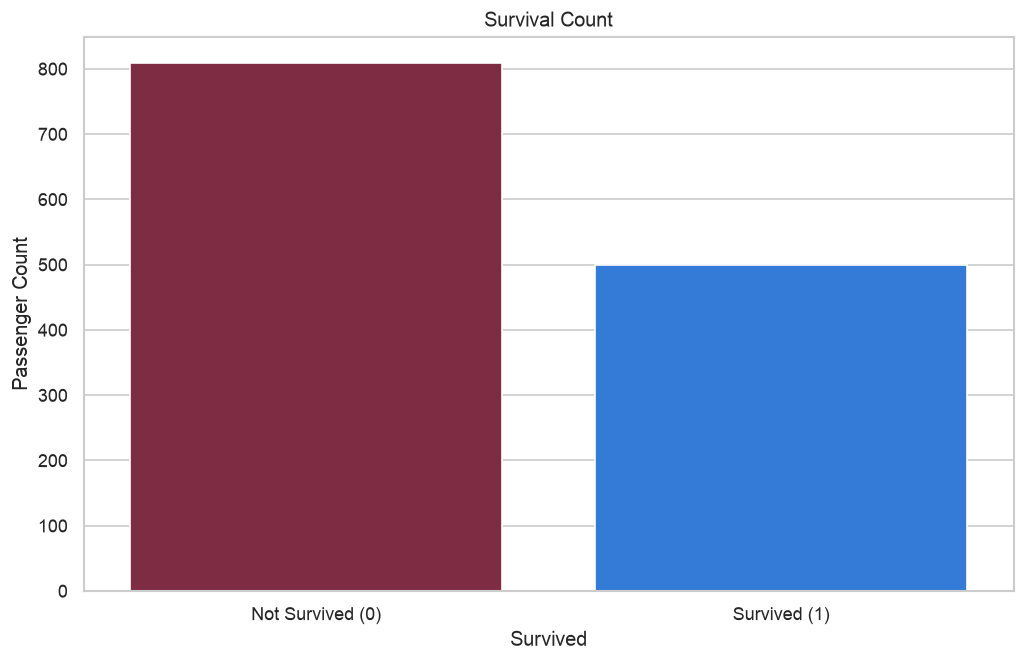

In [5]:
ax = sns.countplot(data=df, x="survived", hue="survived", palette=["#8b1e3f", "#1877f2"], legend=False)
ax.set_title("Survival Count")
ax.set_xlabel("Survived")
ax.set_ylabel("Passenger Count")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Survived (0)", "Survived (1)"])
plt.show()


### Survival by Sex


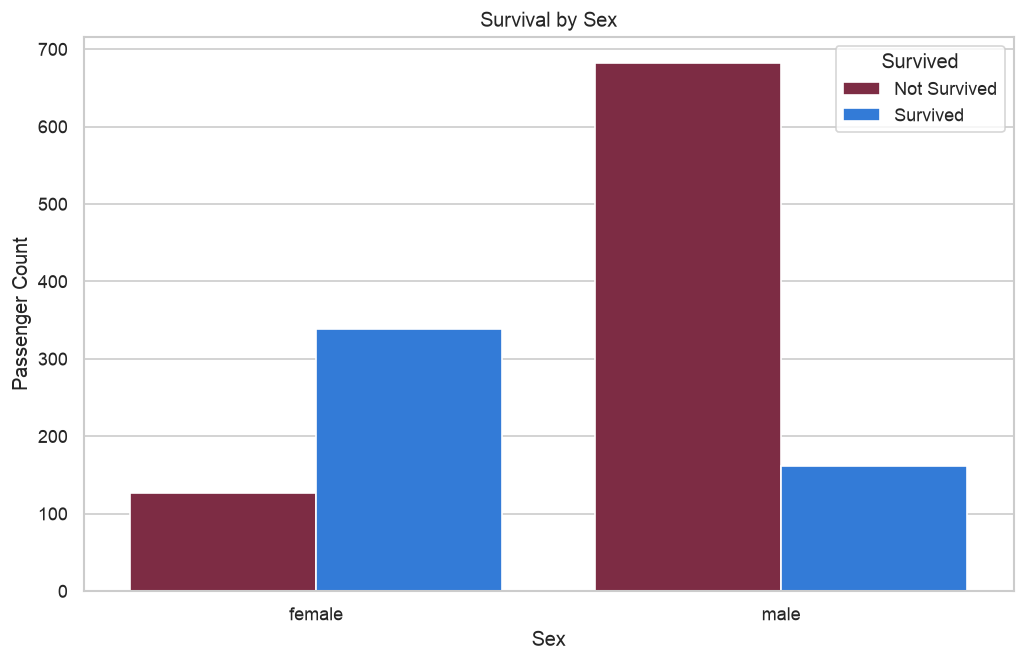

In [6]:
ax = sns.countplot(data=df, x="sex", hue="survived", palette=["#8b1e3f", "#1877f2"])
ax.set_title("Survival by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Passenger Count")
ax.legend(title="Survived", labels=["Not Survived", "Survived"])
plt.show()


### Survival by Passenger Class


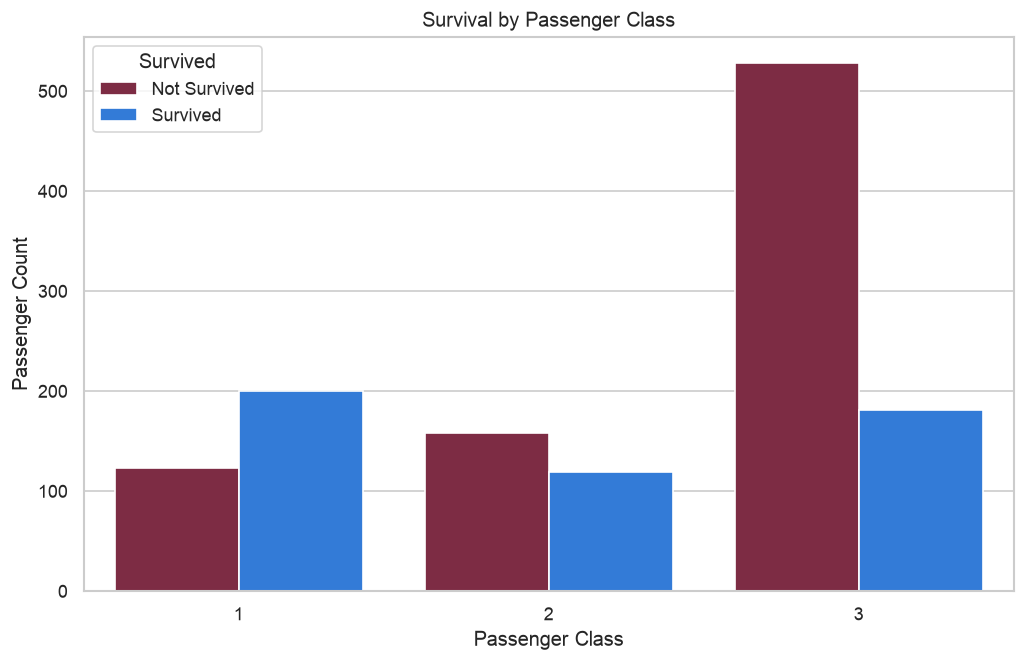

In [7]:
ax = sns.countplot(data=df, x="pclass", hue="survived", palette=["#8b1e3f", "#1877f2"])
ax.set_title("Survival by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Passenger Count")
ax.legend(title="Survived", labels=["Not Survived", "Survived"])
plt.show()


### Survival by Sex and Passenger Class


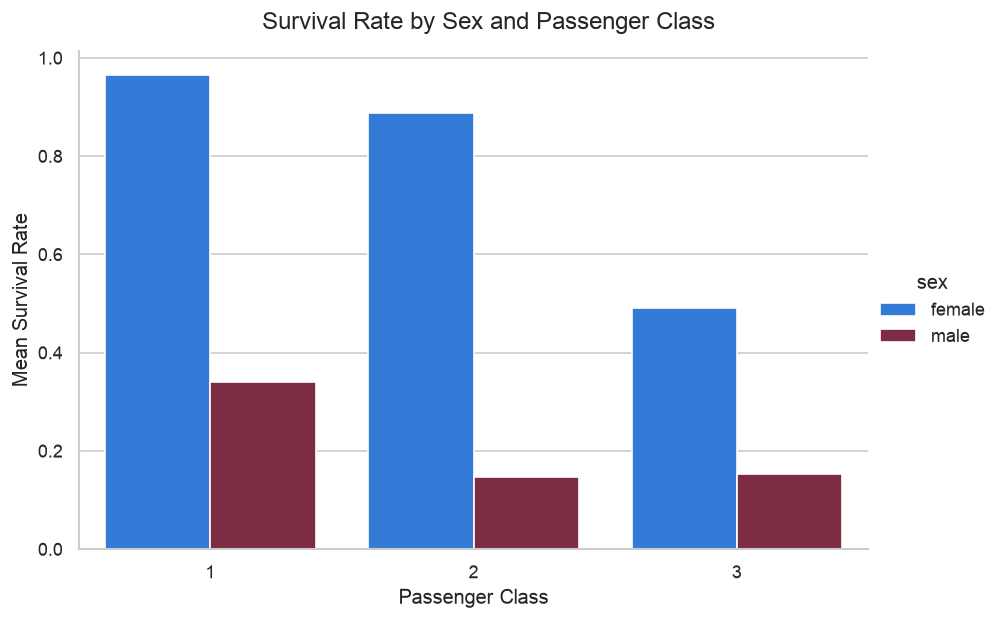

In [8]:
ax = sns.catplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    kind="bar",
    errorbar=None,
    palette=["#1877f2", "#8b1e3f"],
    height=5,
    aspect=1.5,
)
ax.set_axis_labels("Passenger Class", "Mean Survival Rate")
ax.fig.suptitle("Survival Rate by Sex and Passenger Class", y=1.03)
plt.show()


### Age Distribution by Survival


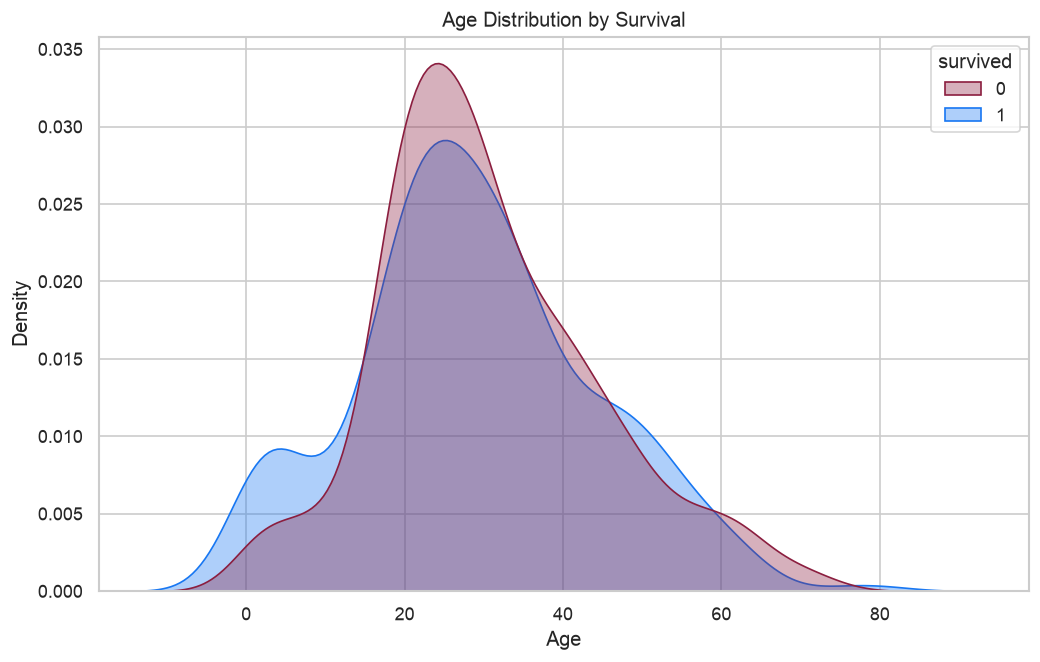

In [9]:
ax = sns.kdeplot(
    data=df,
    x="age",
    hue="survived",
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette=["#8b1e3f", "#1877f2"],
)
ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age")
plt.show()


### Fare Distribution by Survival


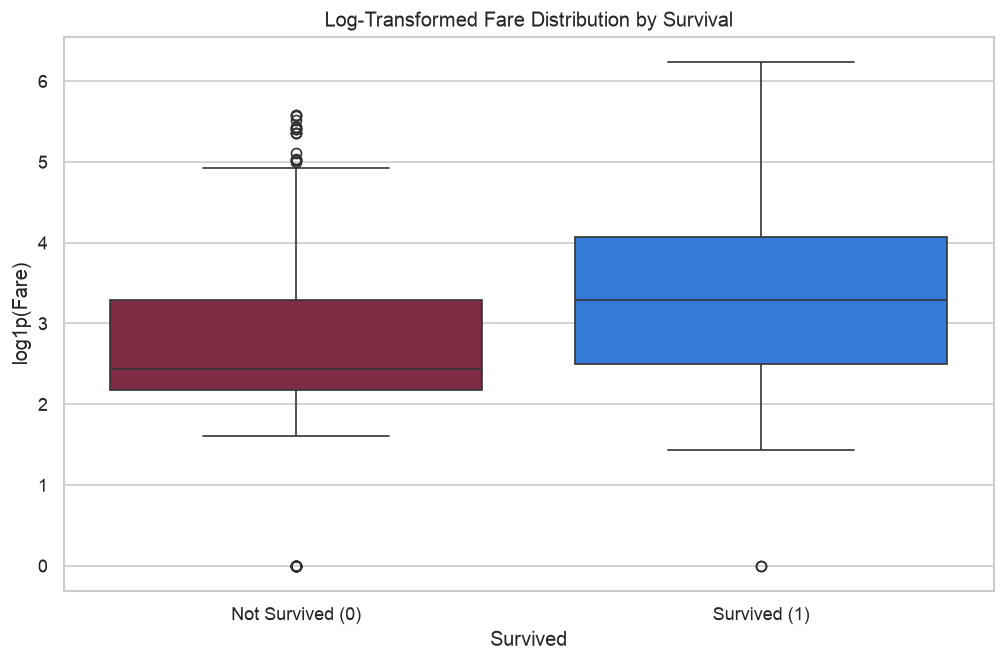

In [10]:
df_plot = df.copy()
df_plot["fare_log1p"] = np.log1p(df_plot["fare"])

ax = sns.boxplot(data=df_plot, x="survived", y="fare_log1p", hue="survived", palette=["#8b1e3f", "#1877f2"], legend=False)
ax.set_title("Log-Transformed Fare Distribution by Survival")
ax.set_xlabel("Survived")
ax.set_ylabel("log1p(Fare)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Survived (0)", "Survived (1)"])
plt.show()


### Embarked vs Survival


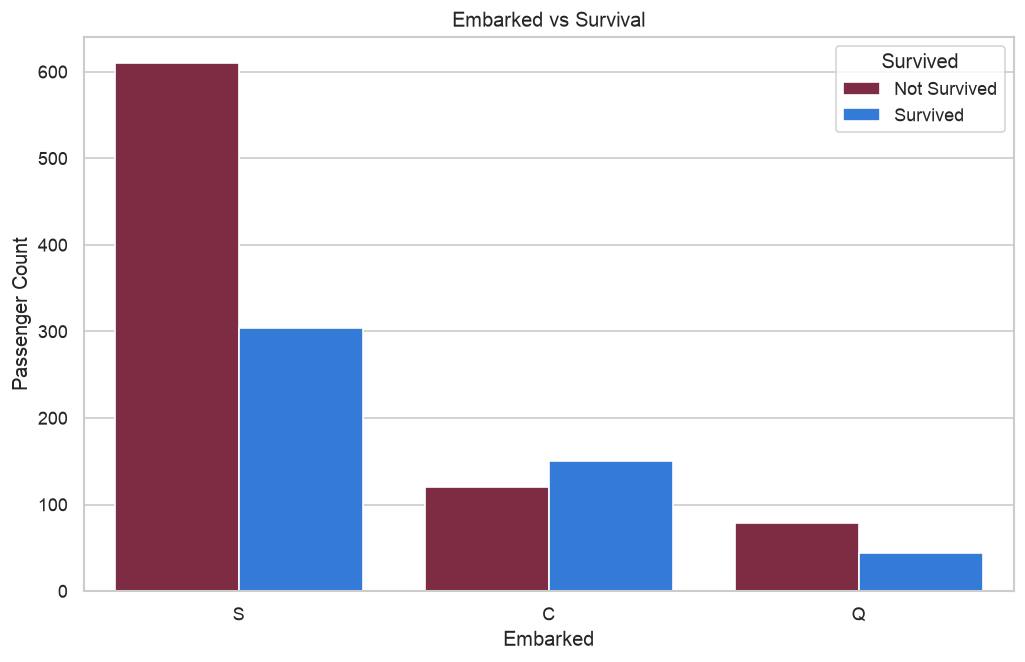

In [11]:
ax = sns.countplot(data=df, x="embarked", hue="survived", palette=["#8b1e3f", "#1877f2"])
ax.set_title("Embarked vs Survival")
ax.set_xlabel("Embarked")
ax.set_ylabel("Passenger Count")
ax.legend(title="Survived", labels=["Not Survived", "Survived"])
plt.show()


### Correlation Heatmap


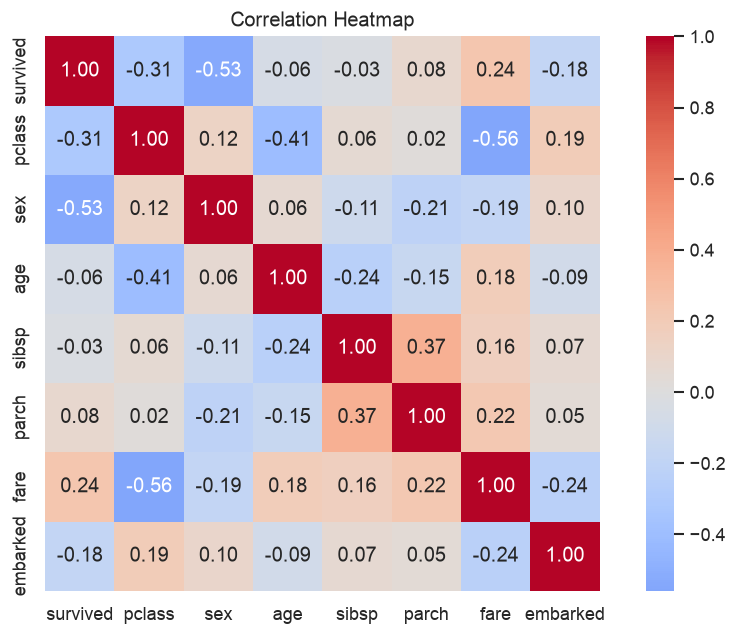

In [12]:
corr_df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
corr_df["sex"] = corr_df["sex"].astype("category").cat.codes
corr_df["embarked"] = corr_df["embarked"].astype("category").cat.codes

corr = corr_df.corr(numeric_only=True)

ax = sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
ax.set_title("Correlation Heatmap")
plt.show()


## 6. Feature Engineering Transformer

We build a custom Scikit-Learn transformer class `TitanicFeatureEngineer` to perform feature engineering.
This creates family features (`family_size`, `is_alone`), extracts names `title` using regular expressions, and sets cabin indicators (`has_cabin`) while cleanly dropping leakage and string variables.


In [13]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create leakage-safe Titanic model features inside the pipeline."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out["family_size"] = X_out["sibsp"] + X_out["parch"] + 1
        X_out["is_alone"] = (X_out["family_size"] == 1).astype(int)

        def extract_title(name):
            if not isinstance(name, str):
                return "Mr"
            match = re.search(r",\s*([^\.]+)\.", name)
            return match.group(1).strip() if match else "Mr"

        X_out["title"] = X_out["name"].apply(extract_title)
        title_mapping = {
            "Mr": "Mr",
            "Mrs": "Mrs",
            "Miss": "Miss",
            "Master": "Master",
            "Mme": "Mrs",
            "Ms": "Miss",
            "Mlle": "Miss",
        }
        X_out["title"] = X_out["title"].map(title_mapping).fillna("Rare")
        X_out["has_cabin"] = X_out["cabin"].notna().astype(int)

        leakage_or_raw = ["passengerid", "name", "ticket", "cabin", "boat", "body", "home_dest"]
        return X_out.drop(columns=[col for col in leakage_or_raw if col in X_out.columns])


## 7. Custom Imputation (Leakage-Safe)

Simple global median imputation ignores passenger demographics. We create a custom `GroupMedianAgeImputer` class that computes median age grouped by passenger class and gender, fitting only on the training folds during cross-validation to prevent data leakage.


In [14]:
class GroupMedianAgeImputer(BaseEstimator, TransformerMixin):
    """Impute missing age from training-fold medians grouped by pclass and sex."""
    def __init__(self, age_col="age", group_cols=("pclass", "sex")):
        self.age_col = age_col
        self.group_cols = group_cols
        self.group_medians_ = {}
        self.global_median_ = None

    def fit(self, X, y=None):
        X_fit = X.copy()
        self.global_median_ = X_fit[self.age_col].median()
        medians = X_fit.groupby(list(self.group_cols), dropna=False)[self.age_col].median()
        self.group_medians_ = medians.to_dict()
        return self

    def transform(self, X):
        X_out = X.copy()
        def fill_age(row):
            if pd.isna(row[self.age_col]):
                key = tuple(row[col] for col in self.group_cols)
                return self.group_medians_.get(key, self.global_median_)
            return row[self.age_col]
        X_out[self.age_col] = X_out.apply(fill_age, axis=1)
        return X_out


## 8. Train/Test Split

We perform a stratified 80-20 partition (`stratify=y`) to split feature attributes and survival targets.


In [15]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "cabin", "name"]
X = df.drop(columns=["survived"])
y = df["survived"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (1047, 13) | Test shape: (262, 13)


## 9. Preprocessing Pipeline

We build a `ColumnTransformer` preprocessing pipeline mapping standard numeric and categorical features.


In [16]:
numeric_features = ["age", "sibsp", "parch", "fare", "family_size"]
categorical_features = ["pclass", "sex", "embarked", "is_alone", "title", "has_cabin"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


## 10. GridSearchCV Model Search

We set up a grid search searching over Logistic Regression hyper-parameters to find the optimal C regularization parameter.


In [17]:
base_pipeline = Pipeline(steps=[
    ("group_age_imputer", GroupMedianAgeImputer()),
    ("feature_engineer", TitanicFeatureEngineer()),
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42))
])

param_grid = {
    "classifier__C": [0.1, 1.0, 10.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("GridSearchCV model search complete.")
print("Best params:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


GridSearchCV model search complete.
Best params: {'classifier__C': 10.0}
Best cross-validation accuracy: 0.8042


## 11. Model Evaluation & ROC Curve

We predict outcomes on the holdout test set using the chosen optimal pipeline and generate accuracy metrics, classification reports, and the ROC curve.


Holdout Test Accuracy: 0.8435
ROC-AUC score: 0.8791

Confusion Matrix:
 [[143  19]
 [ 22  78]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87       162
           1       0.80      0.78      0.79       100

    accuracy                           0.84       262
   macro avg       0.84      0.83      0.83       262
weighted avg       0.84      0.84      0.84       262



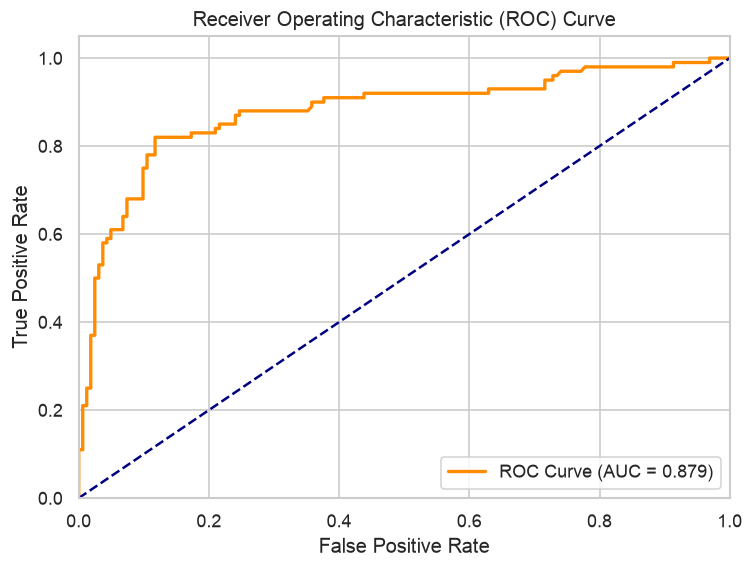

In [18]:
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Holdout Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

def predict_and_print(passenger_df, pipeline_model):
    """Predict survival outcome and probability for passenger scenarios and print in tabular format."""
    prediction = pipeline_model.predict(passenger_df)
    probability = pipeline_model.predict_proba(passenger_df)[:, 1]

    for idx, row in passenger_df.iterrows():
        outcome = "SURVIVES" if prediction[idx] == 1 else "NOT SURVIVED"
        print(f"Passenger: {row['name']:<30} | Class: {row['pclass']} | Sex: {row['sex']:<6} | Probability: {probability[idx]:.4f} ({probability[idx]*100:.1f}%) | Prediction: {outcome}")


## 12. Pipeline Diagram

Displaying the Scikit-Learn visual block diagram of the optimal pipeline.


In [19]:
best_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('group_age_imputer', ...), ('feature_engineer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,age_col,'age'
,group_cols,"('pclass', ...)"
Name,Type,Value
global_median_,float64,28
group_medians_,dict,"{(1, 'female'): 35.0, (1, 'male'): 42.0, (2, 'female'): 27.0, (2, 'male'): 29.0, ...}"


## 13. Log-Odds Coefficients

Displaying feature importances or logistic regression log-odds parameters mapping the direction of influence.


In [20]:
preprocess_step = best_pipeline.named_steps["preprocess"]
encoded_feature_names = preprocess_step.get_feature_names_out()
classifier = best_pipeline.named_steps["classifier"]

if isinstance(classifier, LogisticRegression):
    interpretation = pd.DataFrame({
        "Feature": encoded_feature_names,
        "Coefficient": classifier.coef_[0],
        "Odds Ratio": np.exp(classifier.coef_[0]),
    }).sort_values("Coefficient", ascending=False)
    display(interpretation)
else:
    interpretation = pd.DataFrame({
        "Feature": encoded_feature_names,
        "Importance": classifier.feature_importances_
    }).sort_values("Importance", ascending=False)
    display(interpretation)


,Feature,Coefficient,Odds Ratio
15,cat__has_cabin_1,0.870897,2.389053
3,num__fare,0.062027,1.063991
2,num__parch,-0.071701,0.930809
13,cat__title_Mrs,-0.074582,0.928132
4,num__family_size,-0.307846,0.735028
1,num__sibsp,-0.414239,0.660843
0,num__age,-0.414436,0.660713
5,cat__pclass_2,-0.506300,0.602722
10,cat__is_alone_1,-0.506783,0.602431
9,cat__embarked_S,-0.558058,0.572319


## 14. Economic and Real-World Relevance

The Titanic workflow is universal and applies to modern business categorization needs:
- **Financial risk:** default vs non-default credit underwriting.
- **Disaster response:** locating high-risk zones.
- **Insurance analytics:** evaluating claims.
- **Healthcare triage:** prioritizing patient support.


## 15. Data Science Mindset

- Ask the right questions before coding.
- Clean data is the foundation of truth.
- Visualize to understand.
- Model to predict.
- Communicate to inspire.


## 16. Final Reflection

The Titanic dataset shows that data represents human stories, social structures, and survival outcomes.
Data science is not only coding — it is about asking questions, cleaning carefully, modeling responsibly, and communicating insight.


## 17. Passenger Predictions & Custom Colab Test Sandbox

Evaluating custom passenger scenarios matching the Jupyter notebook showcase profiles.
You can also copy the custom passenger Python script from the companion website sandbox and paste it into the code cell below to run predictions live!


In [21]:
# Setup model variable so copied code runs out-of-the-box
model = best_pipeline

custom_passengers = pd.DataFrame([
    {"pclass": 3, "sex": "male", "age": 22.0, "sibsp": 0, "parch": 0, "fare": 7.25, "embarked": "S", "cabin": np.nan, "name": "Single, Mr. Third Class"},
    {"pclass": 1, "sex": "female", "age": 38.0, "sibsp": 1, "parch": 0, "fare": 71.28, "embarked": "C", "cabin": "C85", "name": "Married, Mrs. First Class"},
    {"pclass": 2, "sex": "male", "age": 6.0, "sibsp": 1, "parch": 1, "fare": 26.00, "embarked": "S", "cabin": np.nan, "name": "Child, Master. Second Class"}
])

print("LIVE SIMULATION PREDICTIONS")
print("=" * 60)
predict_and_print(custom_passengers, model)

# ==============================================================================
# CUSTOM COLAB SANDBOX
# Paste the custom passenger script copied from the website sandbox below:
# ==============================================================================


LIVE SIMULATION PREDICTIONS
Passenger: Single, Mr. Third Class        | Class: 3 | Sex: male   | Probability: 0.1099 (11.0%) | Prediction: NOT SURVIVED
Passenger: Married, Mrs. First Class      | Class: 1 | Sex: female | Probability: 0.9593 (95.9%) | Prediction: SURVIVES
Passenger: Child, Master. Second Class    | Class: 2 | Sex: male   | Probability: 0.7253 (72.5%) | Prediction: SURVIVES
